In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore')

In [2]:
train_df = pd.read_csv("../data/raw/train.csv", parse_dates=['Date'])
test_df  = pd.read_csv("../data/raw/test.csv", parse_dates=['Date'])
store_df = pd.read_csv("../data/raw/store.csv")

In [3]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Store shape:", store_df.shape)

Train shape: (1017209, 9)
Test shape: (41088, 8)
Store shape: (1115, 10)


In [4]:
train_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [5]:
store_df.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [6]:
test_df.head()

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0


In [7]:
train = pd.merge(train_df,store_df,on='Store',how='left')
test = pd.merge(test_df,store_df,on='Store',how='left')

In [8]:
def missing_report(df):

    print((df.isna().sum() / df.shape[0] * 100).sort_values(ascending=False))

print('missing values in train:')
missing_report(train)

missing values in train:
Promo2SinceWeek              49.943620
PromoInterval                49.943620
Promo2SinceYear              49.943620
CompetitionOpenSinceYear     31.787764
CompetitionOpenSinceMonth    31.787764
CompetitionDistance           0.259730
DayOfWeek                     0.000000
Store                         0.000000
Date                          0.000000
Sales                         0.000000
StoreType                     0.000000
SchoolHoliday                 0.000000
StateHoliday                  0.000000
Promo                         0.000000
Open                          0.000000
Customers                     0.000000
Assortment                    0.000000
Promo2                        0.000000
dtype: float64


In [10]:
train['CompetitionDistance'].fillna(train['CompetitionDistance'].quantile(.99),inplace=True)

In [11]:
train['CompetitionOpenSinceMonth'].fillna(0,inplace=True)
train['CompetitionOpenSinceYear'].fillna(0,inplace=True)

In [12]:
train['Promo2SinceWeek'].fillna(0,inplace=True)
train['Promo2SinceYear'].fillna(0,inplace=True)

In [13]:
def paser(df):
    for i in df.select_dtypes('float').columns:
        df[i] = df[i].astype('int')

paser(train)


In [14]:
def time_col(df):
    df['Month'] = df['Date'].dt.month
    df['Year'] = df['Date'].dt.year
    df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)

    df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
    df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)
    df['DayOfWeek_sin'] = np.sin(2 * np.pi * df['DayOfWeek'] / 7)
    df['DayOfWeek_cos'] = np.cos(2 * np.pi * df['DayOfWeek'] / 7)

In [15]:
time_col(train)

In [16]:
train = train[train['Open']==1]

In [17]:
train.describe()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,Month,Year,WeekOfYear,Month_sin,Month_cos,DayOfWeek_sin,DayOfWeek_cos
count,844392.000000,844392.000000,844392,844392.000000,844392.000000,844392.0,844392.000000,844392.000000,844392.00000,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000,8.443920e+05,8.443920e+05,844392.000000,844392.000000
mean,558.422920,3.520361,2014-04-11 01:02:42.487565056,6955.514291,762.728395,1.0,0.446352,0.193580,5538.10961,4.926491,1369.688401,0.498684,11.596118,1003.230065,5.845738,2013.831937,23.646801,1.129539e-01,-6.832069e-02,0.003874,-0.157386
min,1.000000,1.000000,2013-01-01 00:00:00,0.000000,0.000000,1.0,0.000000,0.000000,20.00000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2013.000000,1.000000,-1.000000e+00,-1.000000e+00,-0.974928,-0.900969
25%,280.000000,2.000000,2013-08-16 00:00:00,4859.000000,519.000000,1.0,0.000000,0.000000,710.00000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,2013.000000,11.000000,-5.000000e-01,-8.660254e-01,-0.781831,-0.900969
50%,558.000000,3.000000,2014-03-31 00:00:00,6369.000000,676.000000,1.0,0.000000,0.000000,2330.00000,4.000000,2006.000000,0.000000,0.000000,0.000000,6.000000,2014.000000,23.000000,1.224647e-16,-1.836970e-16,0.433884,-0.222521
75%,837.000000,5.000000,2014-12-10 00:00:00,8360.000000,893.000000,1.0,1.000000,0.000000,6910.00000,9.000000,2011.000000,1.000000,22.000000,2012.000000,8.000000,2014.000000,35.000000,8.660254e-01,5.000000e-01,0.781831,0.623490
max,1115.000000,7.000000,2015-07-31 00:00:00,41551.000000,7388.000000,1.0,1.000000,1.000000,75860.00000,12.000000,2015.000000,1.000000,50.000000,2015.000000,12.000000,2015.000000,52.000000,1.000000e+00,1.000000e+00,0.974928,1.000000
std,321.731914,1.723689,NaN,3104.214680,401.227674,0.0,0.497114,0.395103,7956.33026,4.283663,935.558173,0.499999,15.307873,1005.874806,3.323931,0.777260,14.389785,6.931167e-01,7.086354e-01,0.763951,0.625775


In [18]:
def outlier(df,col):
    Q1 = df[col].quantile(.25)
    Q3 = df[col].quantile(.75)
    IQR = Q3 - Q1
    UB = Q3 + IQR * 1.5
    LB = Q1 - IQR * 1.5
    df[col] = df[col].clip(lower = LB, upper = UB)

<h1>Univariate Analysis</h1>

1. <b>Target Variable (Sales)</b>

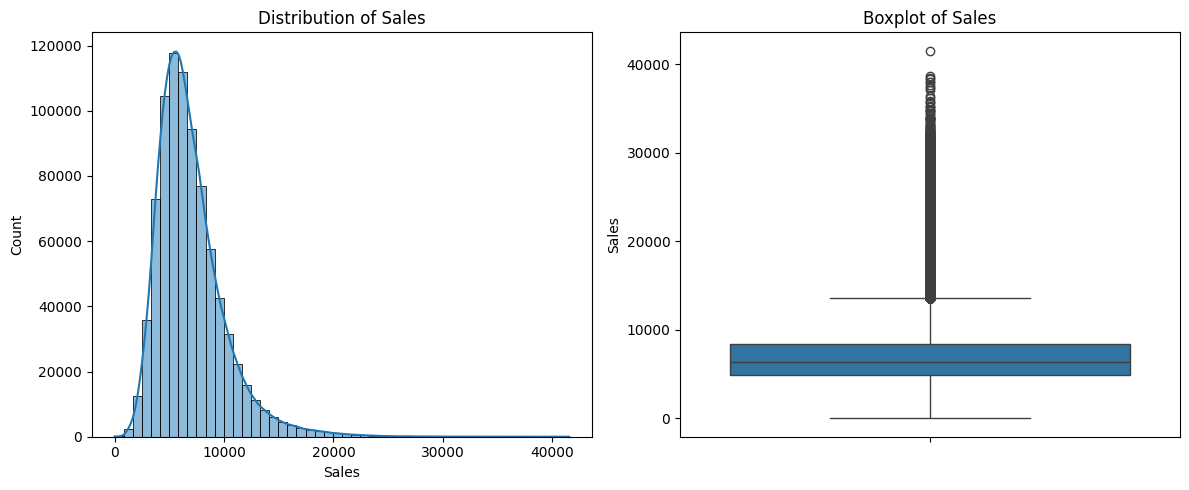

In [19]:
plt.figure(figsize=(12,5))
plt.subplot(121)
sns.histplot(x=train['Sales'],kde=True,bins=50)
plt.title("Distribution of Sales")

plt.subplot(122)
sns.boxplot(train['Sales'])
plt.title("Boxplot of Sales")

plt.tight_layout()
plt.show()

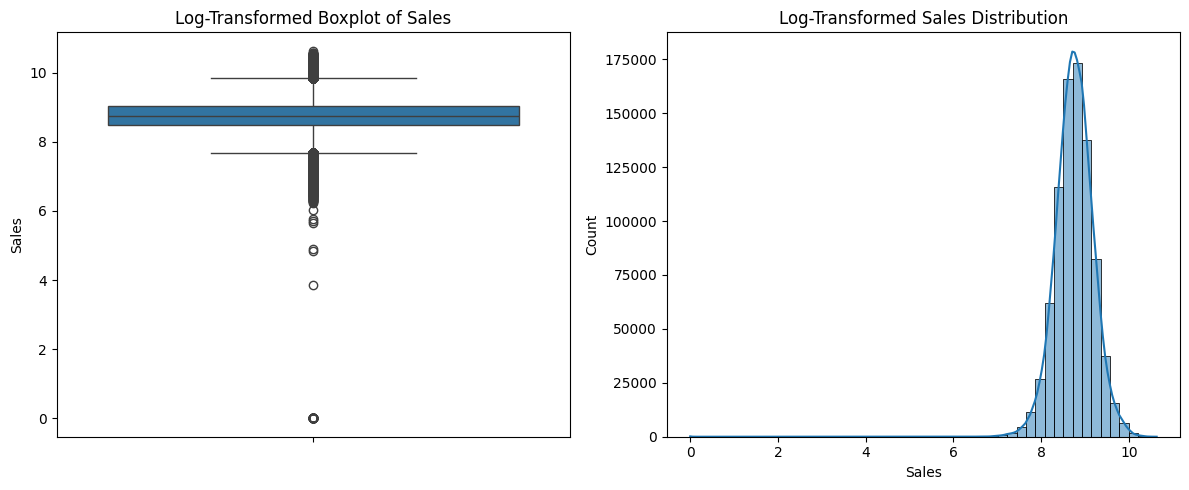

In [20]:
plt.figure(figsize=(12,5))
plt.subplot(121)
sns.boxplot(np.log1p(train['Sales']))
plt.title("Log-Transformed Boxplot of Sales")

plt.subplot(122)
sns.histplot(np.log1p(train['Sales']), kde=True, bins=50)
plt.title("Log-Transformed Sales Distribution")
plt.tight_layout()
plt.show()

In [21]:
train['Sales'] = np.log1p(train['Sales'])
outlier(train,"Sales")


1. Original Sales Distribution
    * The distribution of sales is right-skewed, indicating the presence of a few extreme high sales values that pull the distribution’s tail to the right.
    * The boxplot highlights that while the middle 50% of data lies in the lower sales range, there are numerous extreme outliers on the higher end.

2. Log-Transformed Sales (Log1p)
    * The log-transformed distribution appears left-skewed, largely because of the large number of zero-sales records
    (possibly due to stores being closed or no transactions).
    * The log-transformed boxplot shows a significant reduction in the influence of extreme values, although a few outliers still remain.

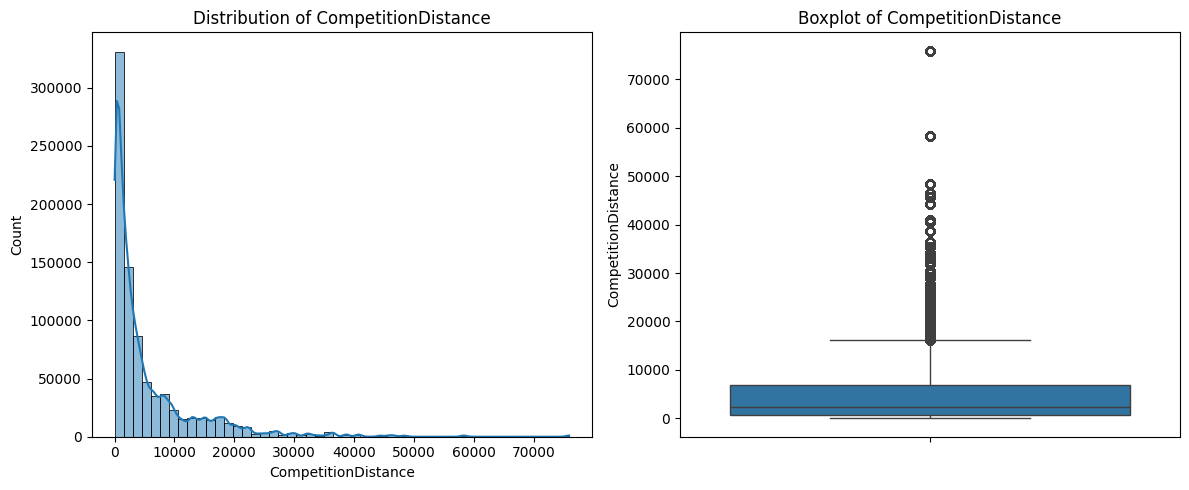

In [22]:
plt.figure(figsize=(12,5))

plt.subplot(121)
sns.histplot(x=train['CompetitionDistance'],kde=True,bins=50)
plt.title("Distribution of CompetitionDistance")

plt.subplot(122)
sns.boxplot(train['CompetitionDistance'])
plt.title("Boxplot of CompetitionDistance")

plt.tight_layout()
plt.show()

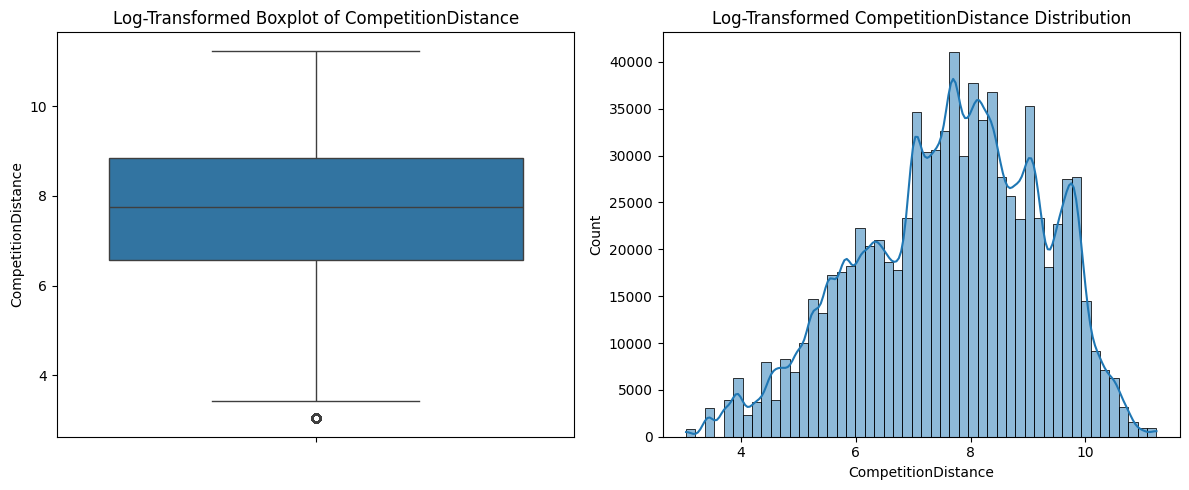

In [23]:
plt.figure(figsize=(12,5))
plt.subplot(121)
sns.boxplot(np.log1p(train['CompetitionDistance']))
plt.title("Log-Transformed Boxplot of CompetitionDistance")

plt.subplot(122)
sns.histplot(np.log1p(train['CompetitionDistance']), kde=True, bins=50)
plt.title("Log-Transformed CompetitionDistance Distribution")
plt.tight_layout()
plt.show()

In [24]:
print(train['CompetitionDistance'].mode()[0])
train['CompetitionDistance'].describe()

250


count    844392.00000
mean       5538.10961
std        7956.33026
min          20.00000
25%         710.00000
50%        2330.00000
75%        6910.00000
max       75860.00000
Name: CompetitionDistance, dtype: float64

1. Original CompetitionDistance Distribution
    * The distribution of CompetitionDistance is right-skewed, indicating the presence of a few extreme high distance values that pull the distribution’s tail to the right.
    * The boxplot highlights that while the middle 50% of data lies in the lower range, there are numerous extreme outliers on the higher end.

2. Log-Transformed CompetitionDistance (Log1p)
    * The log-transformed distribution appears mostly normal.
    * The log-transformed boxplot shows a significant reduction in the influence of extreme values, although a few outliers still remain at the lower end.

In [25]:
def competition(df):
    df['CompetitionAge'] = np.where(df['CompetitionOpenSinceYear'] > 0,
                                    2025 - df['CompetitionOpenSinceYear'], 0)

    df.drop(columns=['CompetitionOpenSinceYear', 'CompetitionOpenSinceMonth'], inplace=True)

In [26]:
competition(train)

In [27]:
train.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear',
       'PromoInterval', 'Month', 'Year', 'WeekOfYear', 'Month_sin',
       'Month_cos', 'DayOfWeek_sin', 'DayOfWeek_cos', 'CompetitionAge'],
      dtype='object')

<h1>EDA</h1>

<h2>1. Univariate Analysis</h2>

In [28]:
def cnt(x):
    df = train[x].value_counts().reset_index()
    df.columns=['x','y']

    plt.figure(figsize=(10, 5))
    bar = sns.barplot(x='x', y='y', data=df)
    bar.bar_label(bar.containers[0])
    plt.title(f"Count of {x}")
    plt.xticks(rotation=45)
    plt.show()


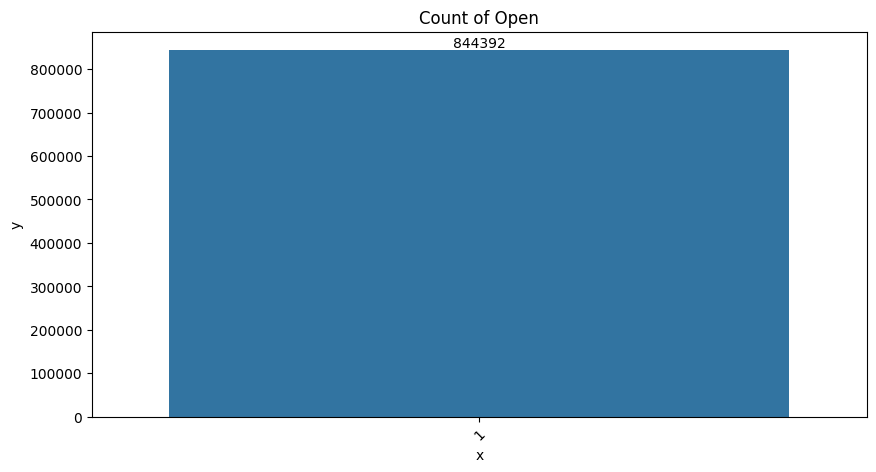

count    844392.0
mean          1.0
std           0.0
min           1.0
25%           1.0
50%           1.0
75%           1.0
max           1.0
Name: Open, dtype: float64


In [29]:
cnt('Open')
print(train['Open'].describe())

*  The vast majority of data points (83%) are for days when stores were open. The days with Open = 0 will have sales of 0 and should likely be filtered out when training the predictive model.

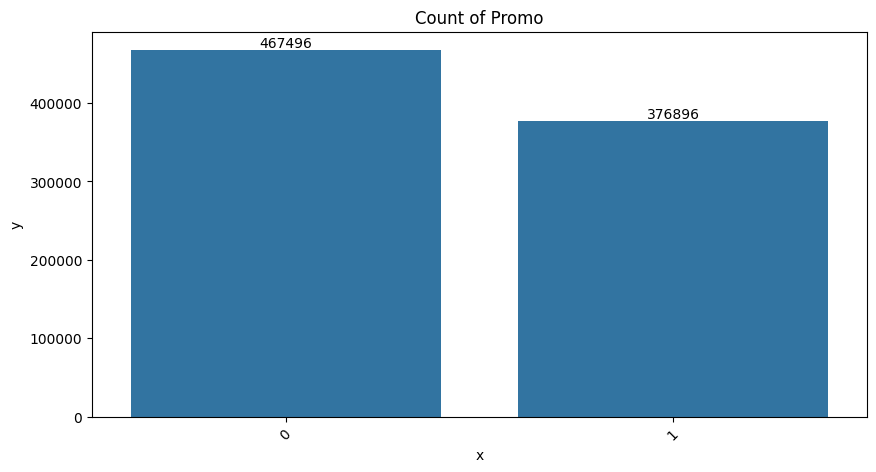

count    844392.000000
mean          0.446352
std           0.497114
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           1.000000
Name: Promo, dtype: float64

In [30]:
cnt('Promo')
train['Promo'].describe()

* Days without a promo (62%) are more common than days with one (38%).*

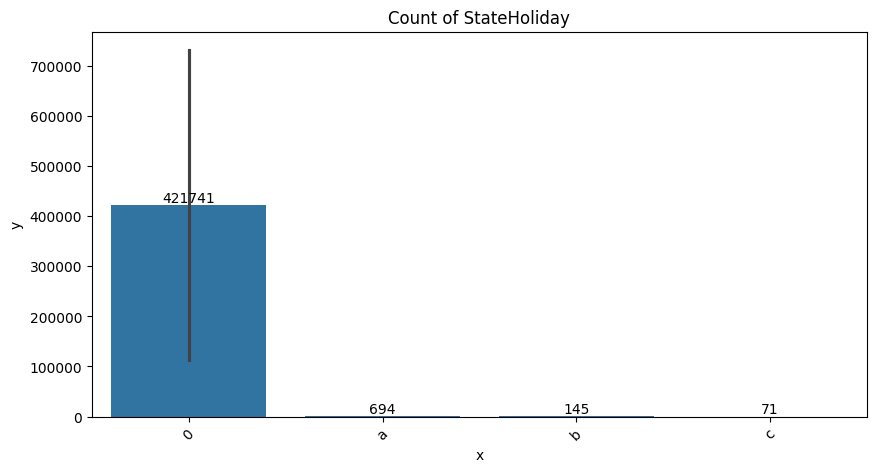

count     844392
unique         5
top            0
freq      731342
Name: StateHoliday, dtype: object

In [31]:
cnt('StateHoliday')
train['StateHoliday'].describe()

* The overwhelming majority of days are not state holidays. Public holidays (a) are the most common type of holiday, but still infrequent compared to a normal day. Easter (b) and Christmas (c) are very rare in the dataset.

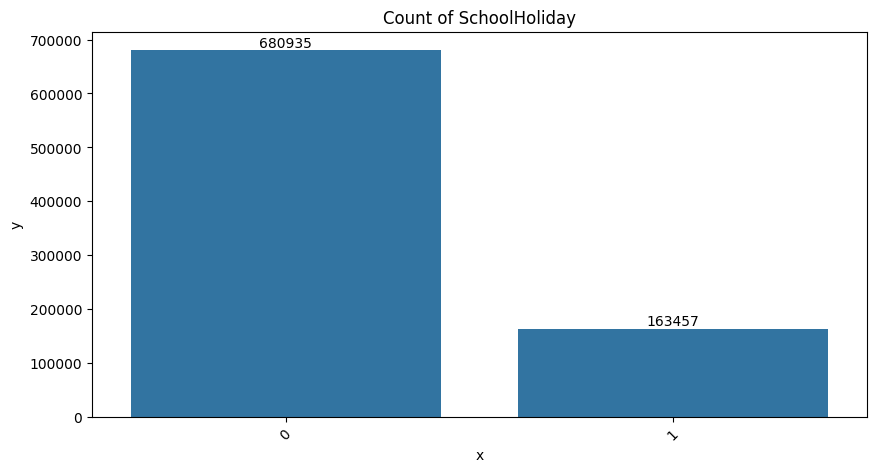

count    844392.000000
mean          0.193580
std           0.395103
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: SchoolHoliday, dtype: float64

In [32]:
cnt('SchoolHoliday')
train['SchoolHoliday'].describe()

* Similarly, only 18% of the days are school holidays.

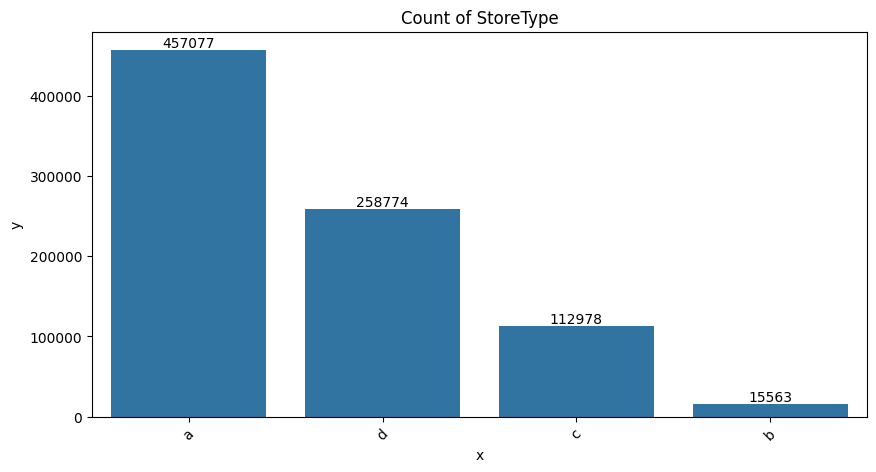

count     844392
unique         4
top            a
freq      457077
Name: StoreType, dtype: object

In [33]:
cnt('StoreType')
train['StoreType'].describe()

* The market is not evenly distributed. Store type a is the most dominant (over 550k entries), followed by d. Type b is by far the least common.

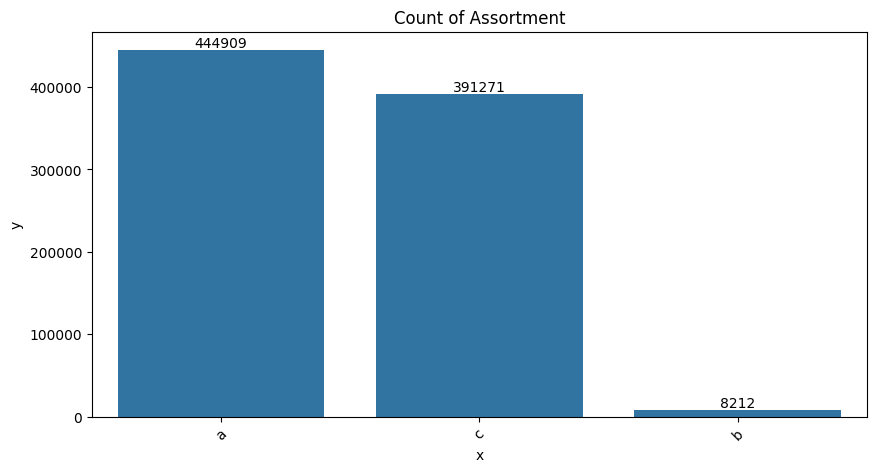

count     844392
unique         3
top            a
freq      444909
Name: Assortment, dtype: object

In [34]:
cnt('Assortment')
train['Assortment'].describe()

* Most stores carry either a (basic) or c (extended) assortment levels, with both being very common. The b (extra) assortment is extremely rare, representing less than 1% of the data.

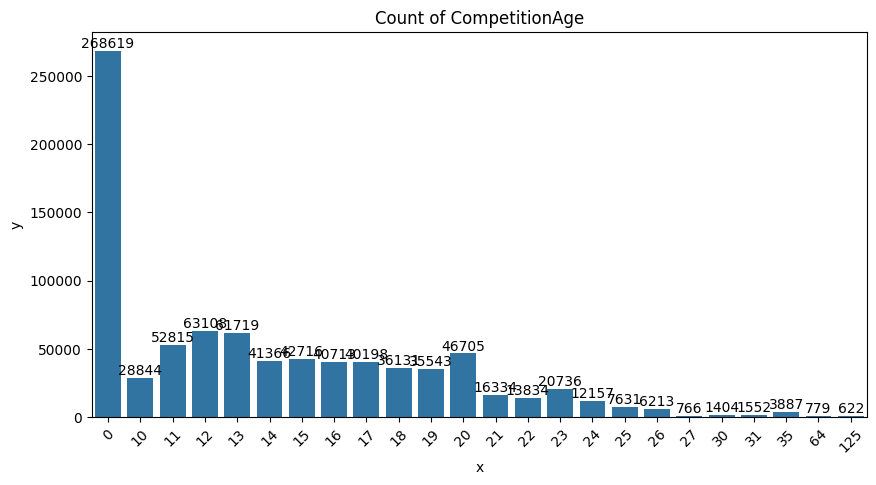

count    844392.000000
mean         11.116161
std           9.056370
min           0.000000
25%           0.000000
50%          13.000000
75%          17.000000
max         125.000000
Name: CompetitionAge, dtype: float64

In [35]:
cnt('CompetitionAge')
train['CompetitionAge'].describe()

* Competitor openings are seasonal, with a strong peak in September (9), and secondary peaks in April (4) and November (11).

* The number of competitor openings has massively accelerated over time. There was a significant boom starting around 2005, which peaked dramatically in 2012 and 2013.

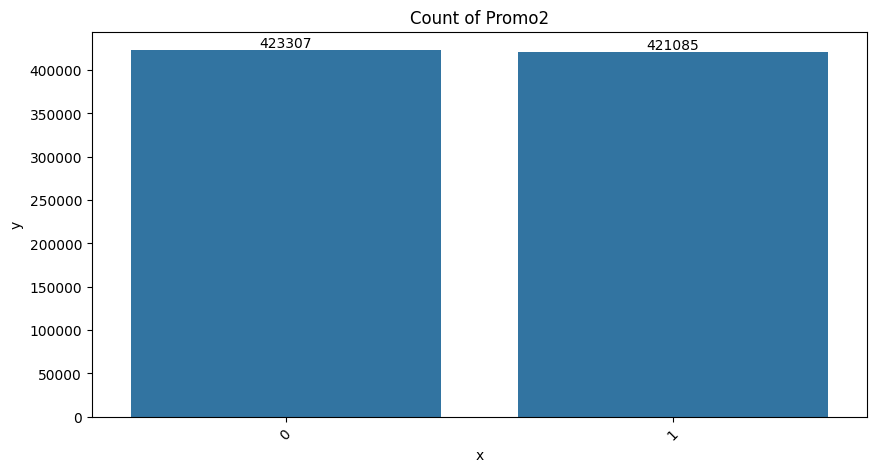

count    844392.000000
mean          0.498684
std           0.499999
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           1.000000
Name: Promo2, dtype: float64

In [36]:
cnt('Promo2')
train['Promo2'].describe()

* continuous promo is a larger, strategic decision, as the dataset is almost perfectly split 50/50 between entries participating and not participating.

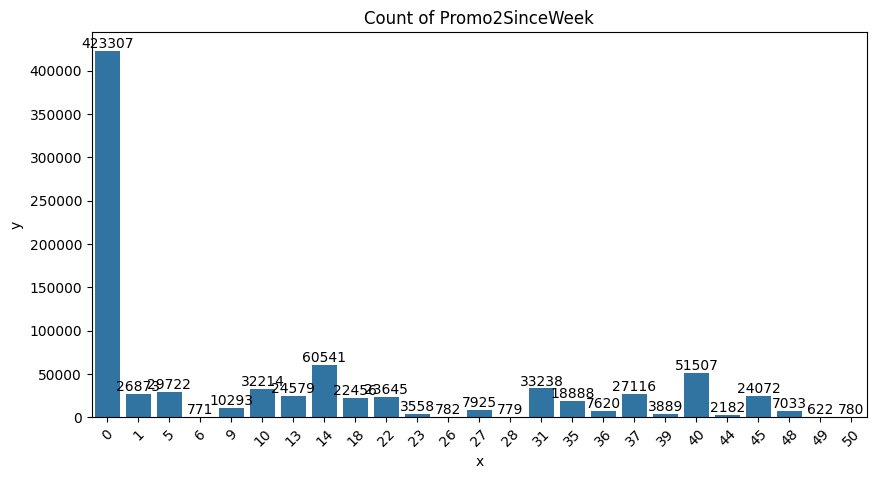

count    844392.000000
mean         11.596118
std          15.307873
min           0.000000
25%           0.000000
50%           0.000000
75%          22.000000
max          50.000000
Name: Promo2SinceWeek, dtype: float64

In [37]:
cnt('Promo2SinceWeek')
train['Promo2SinceWeek'].describe()

* The start weeks for Promo2 are highly concentrated, with major launches around weeks 14, 31, and 40.

<h2> 2. Bivariate Analysis</h2>

In [38]:
from scipy.stats import pearsonr, spearmanr
pearsonr(train['Sales'],train['CompetitionDistance'])

PearsonRResult(statistic=np.float64(-0.033034674672470336), pvalue=np.float64(1.6383324877695333e-202))

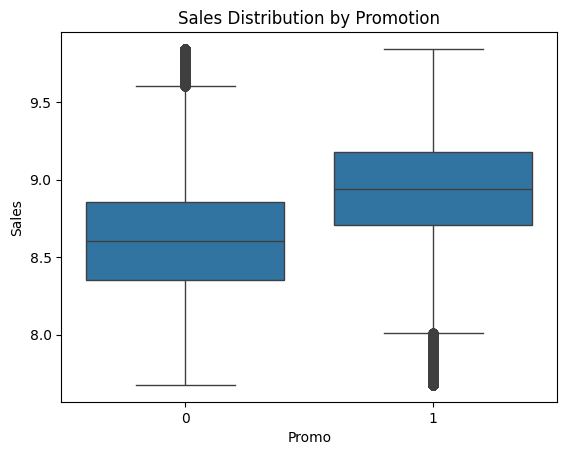

In [39]:
sns.boxplot(x='Promo', y='Sales', data=train)
plt.title('Sales Distribution by Promotion')
plt.show()

* Promotions significantly increase median sales.
* Sales become more variable and less predictable during promotional periods.
* Some promotions fail, resulting in unusually low sales outliers on promo days.

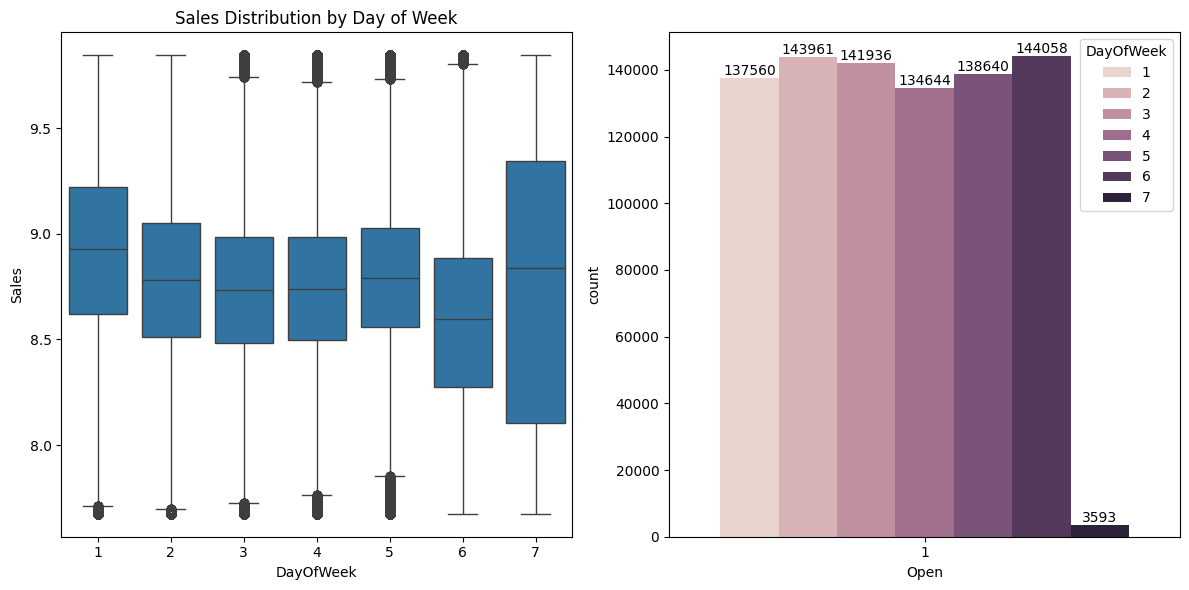

In [40]:
plt.figure(figsize=(12,6))
plt.subplot(121)
sns.boxplot(x='DayOfWeek', y='Sales', data=train)
plt.title('Sales Distribution by Day of Week')

plt.subplot(122)
bar = sns.countplot(x='Open',hue='DayOfWeek',data=train)
for container in bar.containers:
    bar.bar_label(container)
plt.tight_layout()
plt.show()

* Peak Performance: The week's sales peak on Monday and Sunday.
* Weekend Contrast: Saturday (6) is the weakest day for sales, while Sunday is one of the strongest.
* Opportunity: The few stores open on Sunday serve a high-demand market, highlighting a valuable and potentially underserved customer segment.

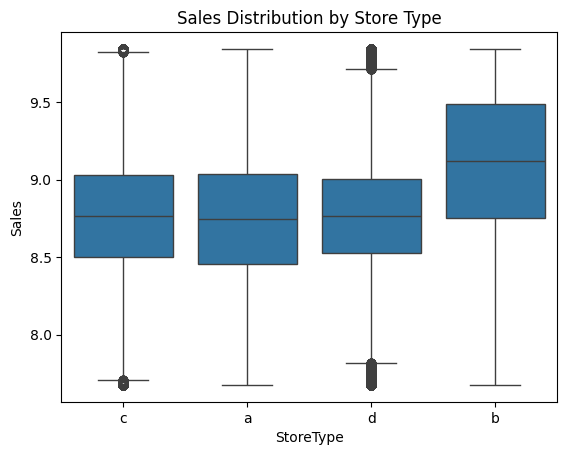

In [41]:
sns.boxplot(x='StoreType', y='Sales', data=train)
plt.title('Sales Distribution by Store Type')
plt.show()

* Top Performer: Store Type 'b' is the clear top performer, showing significantly higher median sales than all other types.
* Consistent Group: Store Types 'a', 'c', and 'd' perform similarly to each other, with their median sales clustered closely together.
* Highest Variability: Store Type 'b' also has the widest interquartile range, indicating its sales performance is the most variable.

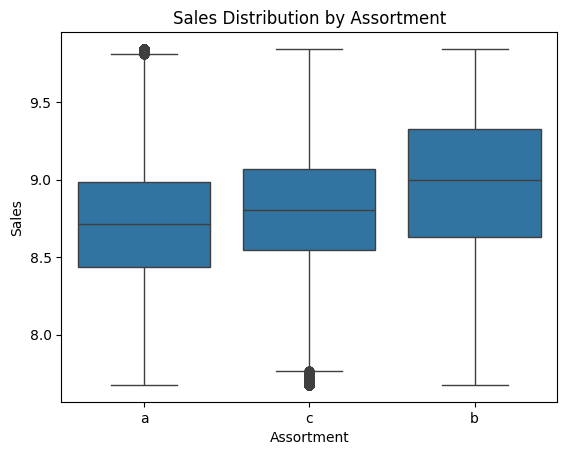

In [42]:
sns.boxplot(x='Assortment', y='Sales', data=train)
plt.title('Sales Distribution by Assortment')
plt.show()

* Top Performer: Assortment 'b' (extra) generates the highest median sales, indicating it's the most profitable product strategy.
* Sales Variability: Assortment 'b' also has the widest sales range (the tallest box), meaning its performance is the most variable.
* Outlier Behavior: Assortment 'c' (extended) has a noticeable cluster of low-end outliers, suggesting that while it generally performs well, it's prone to occasional, unusually poor sales days.

In [43]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 844392 entries, 0 to 1017190
Data columns (total 24 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   Store                844392 non-null  int64         
 1   DayOfWeek            844392 non-null  int64         
 2   Date                 844392 non-null  datetime64[ns]
 3   Sales                844392 non-null  float64       
 4   Customers            844392 non-null  int64         
 5   Open                 844392 non-null  int64         
 6   Promo                844392 non-null  int64         
 7   StateHoliday         844392 non-null  object        
 8   SchoolHoliday        844392 non-null  int64         
 9   StoreType            844392 non-null  object        
 10  Assortment           844392 non-null  object        
 11  CompetitionDistance  844392 non-null  int64         
 12  Promo2               844392 non-null  int64         
 13  Promo2SinceWeek   

In [44]:
train.select_dtypes('O').columns

Index(['StateHoliday', 'StoreType', 'Assortment', 'PromoInterval'], dtype='object')

In [45]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
def encoding(df):
    month_map = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6, 'Jul': 7, 'Aug': 8, 'Sept': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12}

    for col in df.select_dtypes('O').columns:
        if col == 'PromoInterval':
            df[col] = df[col].fillna('')
            df[col] = df[col].astype(str)
            df[col] = df[col].apply(
                lambda x: [month_map[m] for m in x.split(',')] if x != '' else []
            )
        else:  
            df[col] = df[col].astype(str)
            df[col] = le.fit_transform(df[col])
    
    return df

In [46]:
encoding(train)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Month,Year,WeekOfYear,Month_sin,Month_cos,DayOfWeek_sin,DayOfWeek_cos,CompetitionAge
0,1,5,2015-07-31,8.568646,555,1,1,0,1,2,0,1270,0,0,0,[],7,2015,31,-0.5,-0.866025,-0.974928,-0.222521,17
1,2,5,2015-07-31,8.710290,625,1,1,0,1,0,0,570,1,13,2010,"[1, 4, 7, 10]",7,2015,31,-0.5,-0.866025,-0.974928,-0.222521,18
2,3,5,2015-07-31,9.025816,821,1,1,0,1,0,0,14130,1,14,2011,"[1, 4, 7, 10]",7,2015,31,-0.5,-0.866025,-0.974928,-0.222521,19
3,4,5,2015-07-31,9.546527,1498,1,1,0,1,2,2,620,0,0,0,[],7,2015,31,-0.5,-0.866025,-0.974928,-0.222521,16
4,5,5,2015-07-31,8.481151,559,1,1,0,1,0,0,29910,0,0,0,[],7,2015,31,-0.5,-0.866025,-0.974928,-0.222521,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016776,682,2,2013-01-01,8.124447,566,1,0,1,1,1,0,150,0,0,0,[],1,2013,1,0.5,0.866025,0.974928,-0.222521,19
1016827,733,2,2013-01-01,9.284148,2377,1,0,1,1,1,1,860,0,0,0,[],1,2013,1,0.5,0.866025,0.974928,-0.222521,26
1016863,769,2,2013-01-01,8.524367,1248,1,0,1,1,1,1,840,1,48,2012,"[1, 4, 7, 10]",1,2013,1,0.5,0.866025,0.974928,-0.222521,0
1017042,948,2,2013-01-01,8.410053,1039,1,0,1,1,1,1,1430,0,0,0,[],1,2013,1,0.5,0.866025,0.974928,-0.222521,0


In [47]:
def check_promo_month(df):
    df['IsPromoMonth'] = df.apply(
        lambda row: 1 if row['Month'] in row['PromoInterval'] else 0,
        axis=1
    )
    df.drop(columns='PromoInterval', inplace=True)
    return df

In [48]:
check_promo_month(train)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,Promo2,Promo2SinceWeek,Promo2SinceYear,Month,Year,WeekOfYear,Month_sin,Month_cos,DayOfWeek_sin,DayOfWeek_cos,CompetitionAge,IsPromoMonth
0,1,5,2015-07-31,8.568646,555,1,1,0,1,2,0,1270,0,0,0,7,2015,31,-0.5,-0.866025,-0.974928,-0.222521,17,0
1,2,5,2015-07-31,8.710290,625,1,1,0,1,0,0,570,1,13,2010,7,2015,31,-0.5,-0.866025,-0.974928,-0.222521,18,1
2,3,5,2015-07-31,9.025816,821,1,1,0,1,0,0,14130,1,14,2011,7,2015,31,-0.5,-0.866025,-0.974928,-0.222521,19,1
3,4,5,2015-07-31,9.546527,1498,1,1,0,1,2,2,620,0,0,0,7,2015,31,-0.5,-0.866025,-0.974928,-0.222521,16,0
4,5,5,2015-07-31,8.481151,559,1,1,0,1,0,0,29910,0,0,0,7,2015,31,-0.5,-0.866025,-0.974928,-0.222521,10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016776,682,2,2013-01-01,8.124447,566,1,0,1,1,1,0,150,0,0,0,1,2013,1,0.5,0.866025,0.974928,-0.222521,19,0
1016827,733,2,2013-01-01,9.284148,2377,1,0,1,1,1,1,860,0,0,0,1,2013,1,0.5,0.866025,0.974928,-0.222521,26,0
1016863,769,2,2013-01-01,8.524367,1248,1,0,1,1,1,1,840,1,48,2012,1,2013,1,0.5,0.866025,0.974928,-0.222521,0,1
1017042,948,2,2013-01-01,8.410053,1039,1,0,1,1,1,1,1430,0,0,0,1,2013,1,0.5,0.866025,0.974928,-0.222521,0,0


In [49]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 844392 entries, 0 to 1017190
Data columns (total 24 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   Store                844392 non-null  int64         
 1   DayOfWeek            844392 non-null  int64         
 2   Date                 844392 non-null  datetime64[ns]
 3   Sales                844392 non-null  float64       
 4   Customers            844392 non-null  int64         
 5   Open                 844392 non-null  int64         
 6   Promo                844392 non-null  int64         
 7   StateHoliday         844392 non-null  int64         
 8   SchoolHoliday        844392 non-null  int64         
 9   StoreType            844392 non-null  int64         
 10  Assortment           844392 non-null  int64         
 11  CompetitionDistance  844392 non-null  int64         
 12  Promo2               844392 non-null  int64         
 13  Promo2SinceWeek   

In [50]:
from sklearn.model_selection import train_test_split
train.drop(columns=['Date', 'Customers', 'Open'], inplace=True)
X = train.drop('Sales', axis=1)
y = train['Sales']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [51]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

y_pred_original = np.expm1(lr_pred)
y_test_original = np.expm1(y_test)

lr_rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
print(f"Linear Regression RMSE: {lr_rmse:.2f}")
r2_score(y_test,lr_pred)

Linear Regression RMSE: 2672.81


0.24248255105143024

* Sales patterns are non-linear.
* The success of drivers like promotions is highly interactive, depending heavily on other factors like the store type and day.

In [52]:
from sklearn.tree import DecisionTreeRegressor
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
print(f"Decision Tree RMSE: {dt_rmse:.2f}")
r2_score(y_test,dt_pred)

Decision Tree RMSE: 0.17


0.8350159114012647

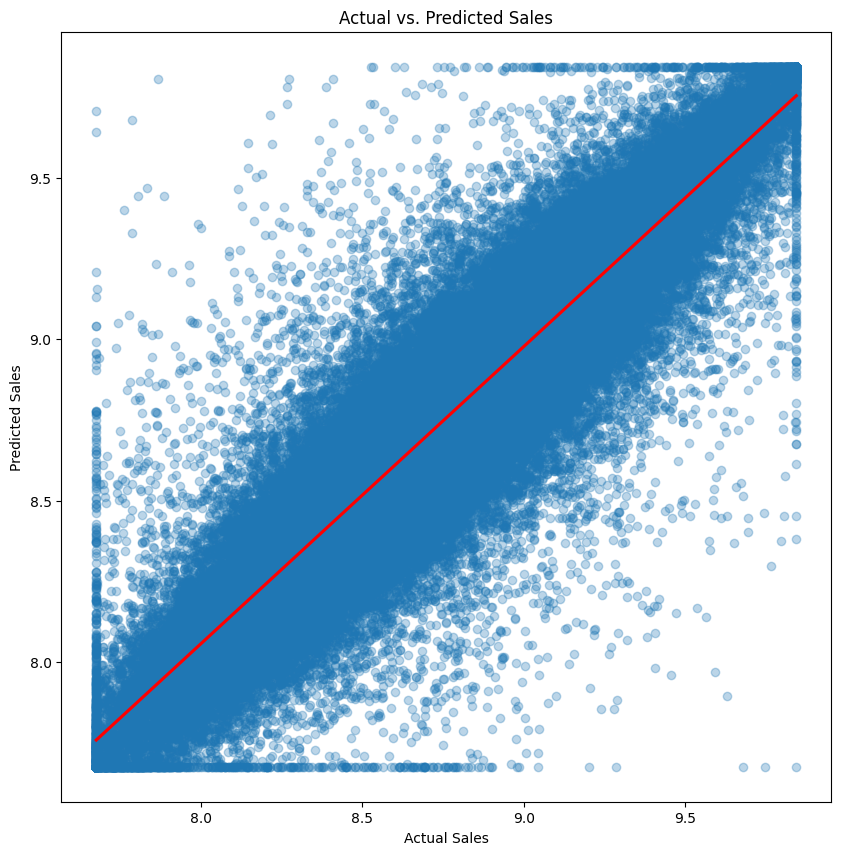

In [53]:
plt.figure(figsize=(10, 10))

sns.regplot(x=y_test, y=dt_pred, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs. Predicted Sales")
plt.axis('equal')
plt.axis('square')
plt.show()

In [54]:
import xgboost as xgb
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric='rmse'
)
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

print(f"The Root Mean Squared Error (RMSE) on the validation set is: {rmse:.2f}")
r2_score(y_test,xgb_pred)

The Root Mean Squared Error (RMSE) on the validation set is: 0.16


0.8517270487903846

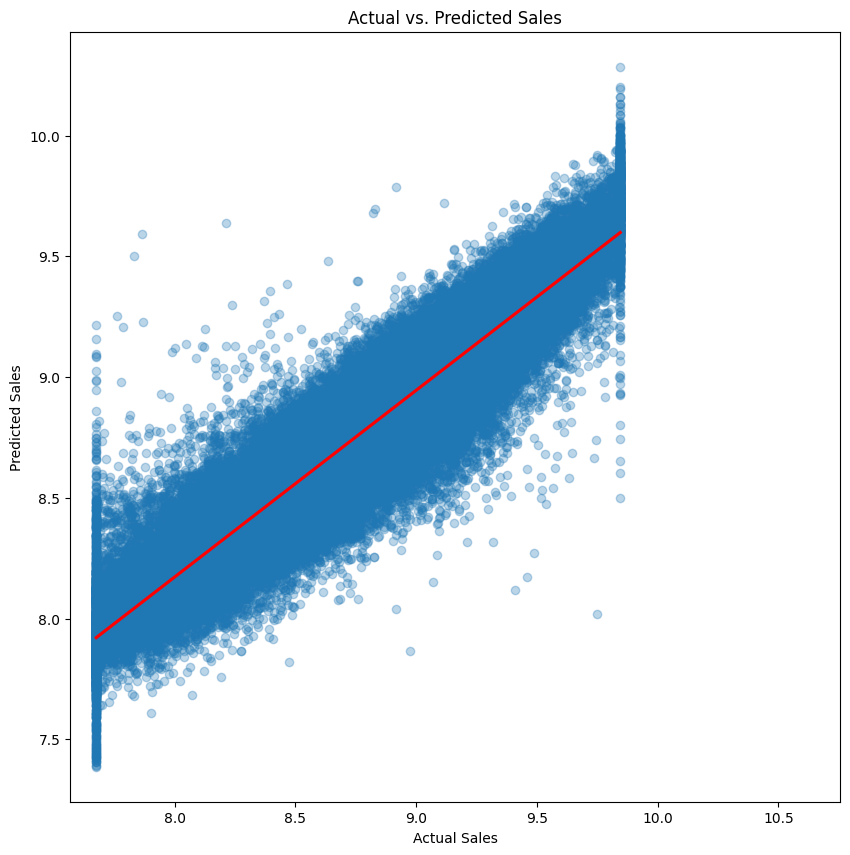

In [55]:
plt.figure(figsize=(10, 10))

sns.regplot(x=y_test, y=xgb_pred, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs. Predicted Sales")
plt.axis('equal')
plt.axis('square')
plt.show()

* The plot shows a strong, positive correlation between the model's predictions and the actual sales.
* The tight, symmetrical clustering around the red line visually confirms the model's high accuracy and lack of bias.
* The model's performance is consistent across all sales levels, from low to high.

In [56]:
test

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,1,4,2015-09-17,1.0,1,0,0,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,3,4,2015-09-17,1.0,1,0,0,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
2,3,7,4,2015-09-17,1.0,1,0,0,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
3,4,8,4,2015-09-17,1.0,1,0,0,a,a,7520.0,10.0,2014.0,0,NaN,NaN,NaN
4,5,9,4,2015-09-17,1.0,1,0,0,a,c,2030.0,8.0,2000.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41083,41084,1111,6,2015-08-01,1.0,0,0,0,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
41084,41085,1112,6,2015-08-01,1.0,0,0,0,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
41085,41086,1113,6,2015-08-01,1.0,0,0,0,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
41086,41087,1114,6,2015-08-01,1.0,0,0,0,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [57]:
missing_report(test)

PromoInterval                41.939252
Promo2SinceYear              41.939252
Promo2SinceWeek              41.939252
CompetitionOpenSinceMonth    37.032710
CompetitionOpenSinceYear     37.032710
CompetitionDistance           0.233645
Open                          0.026772
Id                            0.000000
Store                         0.000000
StoreType                     0.000000
SchoolHoliday                 0.000000
StateHoliday                  0.000000
Promo                         0.000000
Date                          0.000000
DayOfWeek                     0.000000
Assortment                    0.000000
Promo2                        0.000000
dtype: float64


In [58]:
test['Promo2SinceWeek'].fillna(0,inplace=True)
test['Promo2SinceYear'].fillna(0,inplace=True)
test['CompetitionDistance'].fillna(test['CompetitionDistance'].quantile(.99),inplace=True)
test['Open'].fillna(0,inplace=True)

In [59]:
test['CompetitionOpenSinceMonth'].fillna(0,inplace=True)
test['CompetitionOpenSinceYear'].fillna(0,inplace=True)

In [60]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41088 entries, 0 to 41087
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Id                         41088 non-null  int64         
 1   Store                      41088 non-null  int64         
 2   DayOfWeek                  41088 non-null  int64         
 3   Date                       41088 non-null  datetime64[ns]
 4   Open                       41088 non-null  float64       
 5   Promo                      41088 non-null  int64         
 6   StateHoliday               41088 non-null  object        
 7   SchoolHoliday              41088 non-null  int64         
 8   StoreType                  41088 non-null  object        
 9   Assortment                 41088 non-null  object        
 10  CompetitionDistance        41088 non-null  float64       
 11  CompetitionOpenSinceMonth  41088 non-null  float64       
 12  Comp

In [61]:
missing_report(test)

PromoInterval                41.939252
Id                            0.000000
Store                         0.000000
Date                          0.000000
DayOfWeek                     0.000000
Promo                         0.000000
StateHoliday                  0.000000
SchoolHoliday                 0.000000
Open                          0.000000
StoreType                     0.000000
Assortment                    0.000000
CompetitionOpenSinceMonth     0.000000
CompetitionDistance           0.000000
CompetitionOpenSinceYear      0.000000
Promo2                        0.000000
Promo2SinceWeek               0.000000
Promo2SinceYear               0.000000
dtype: float64


In [62]:
paser(test)

In [63]:
time_col(test)

In [64]:
competition(test)

In [65]:
encoding(test)

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Month,Year,WeekOfYear,Month_sin,Month_cos,DayOfWeek_sin,DayOfWeek_cos,CompetitionAge
0,1,1,4,2015-09-17,1,1,0,0,2,0,1270,0,0,0,[],9,2015,38,-1.000000,-1.836970e-16,-0.433884,-0.900969,17
1,2,3,4,2015-09-17,1,1,0,0,0,0,14130,1,14,2011,"[1, 4, 7, 10]",9,2015,38,-1.000000,-1.836970e-16,-0.433884,-0.900969,19
2,3,7,4,2015-09-17,1,1,0,0,0,2,24000,0,0,0,[],9,2015,38,-1.000000,-1.836970e-16,-0.433884,-0.900969,12
3,4,8,4,2015-09-17,1,1,0,0,0,0,7520,0,0,0,[],9,2015,38,-1.000000,-1.836970e-16,-0.433884,-0.900969,11
4,5,9,4,2015-09-17,1,1,0,0,0,2,2030,0,0,0,[],9,2015,38,-1.000000,-1.836970e-16,-0.433884,-0.900969,25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41083,41084,1111,6,2015-08-01,1,0,0,0,0,0,1900,1,31,2013,"[1, 4, 7, 10]",8,2015,31,-0.866025,-5.000000e-01,-0.781831,0.623490,11
41084,41085,1112,6,2015-08-01,1,0,0,0,2,2,1880,0,0,0,[],8,2015,31,-0.866025,-5.000000e-01,-0.781831,0.623490,19
41085,41086,1113,6,2015-08-01,1,0,0,0,0,2,9260,0,0,0,[],8,2015,31,-0.866025,-5.000000e-01,-0.781831,0.623490,0
41086,41087,1114,6,2015-08-01,1,0,0,0,0,2,870,0,0,0,[],8,2015,31,-0.866025,-5.000000e-01,-0.781831,0.623490,0


In [66]:
check_promo_month(test)

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,Promo2,Promo2SinceWeek,Promo2SinceYear,Month,Year,WeekOfYear,Month_sin,Month_cos,DayOfWeek_sin,DayOfWeek_cos,CompetitionAge,IsPromoMonth
0,1,1,4,2015-09-17,1,1,0,0,2,0,1270,0,0,0,9,2015,38,-1.000000,-1.836970e-16,-0.433884,-0.900969,17,0
1,2,3,4,2015-09-17,1,1,0,0,0,0,14130,1,14,2011,9,2015,38,-1.000000,-1.836970e-16,-0.433884,-0.900969,19,0
2,3,7,4,2015-09-17,1,1,0,0,0,2,24000,0,0,0,9,2015,38,-1.000000,-1.836970e-16,-0.433884,-0.900969,12,0
3,4,8,4,2015-09-17,1,1,0,0,0,0,7520,0,0,0,9,2015,38,-1.000000,-1.836970e-16,-0.433884,-0.900969,11,0
4,5,9,4,2015-09-17,1,1,0,0,0,2,2030,0,0,0,9,2015,38,-1.000000,-1.836970e-16,-0.433884,-0.900969,25,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41083,41084,1111,6,2015-08-01,1,0,0,0,0,0,1900,1,31,2013,8,2015,31,-0.866025,-5.000000e-01,-0.781831,0.623490,11,0
41084,41085,1112,6,2015-08-01,1,0,0,0,2,2,1880,0,0,0,8,2015,31,-0.866025,-5.000000e-01,-0.781831,0.623490,19,0
41085,41086,1113,6,2015-08-01,1,0,0,0,0,2,9260,0,0,0,8,2015,31,-0.866025,-5.000000e-01,-0.781831,0.623490,0,0
41086,41087,1114,6,2015-08-01,1,0,0,0,0,2,870,0,0,0,8,2015,31,-0.866025,-5.000000e-01,-0.781831,0.623490,0,0


In [67]:
test.columns

Index(['Id', 'Store', 'DayOfWeek', 'Date', 'Open', 'Promo', 'StateHoliday',
       'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance',
       'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'Month', 'Year',
       'WeekOfYear', 'Month_sin', 'Month_cos', 'DayOfWeek_sin',
       'DayOfWeek_cos', 'CompetitionAge', 'IsPromoMonth'],
      dtype='object')

In [68]:
test_ids = test['Id']
test.drop(columns=['Date', 'Id','Open'], inplace=True)

In [69]:
sub = model.predict(test)
sub = np.expm1(sub)

In [70]:
submission_df = pd.DataFrame({'Id': test_ids, 'Sales': sub})
submission_df.to_csv('submission.csv', index=False)